# example of reading one trace

In [1]:
using Pkg

cd(@__DIR__)
Pkg.activate("../")
using Dates, SonifSismo, CairoMakie

  Activating project at `~/Documents/Github/sonifSismo.jl`


In [2]:
archive = DataArchive("/Users/nobuaki/Documents/mtFujiContinuous")

DataArchive("/Users/nobuaki/Documents/mtFujiContinuous", "/Users/nobuaki/Documents/mtFujiContinuous/mseed", "/Users/nobuaki/Documents/mtFujiContinuous/catalog/h2008", :JST, Hour(9))

In [3]:

available_stations(archive)
available_channels(archive)

33-element Vector{ChannelAvailability}:
 ChannelAvailability("EV", "FJO", "", "E", [Date("2008-05-25"), Date("2008-05-26"), Date("2008-05-27"), Date("2008-05-28"), Date("2008-05-29"), Date("2008-05-30"), Date("2008-05-31")], ["/Users/nobuaki/Documents/mtFujiContinuous/mseed/2008/05/25/EV.FJO..E.20080525.mseed", "/Users/nobuaki/Documents/mtFujiContinuous/mseed/2008/05/26/EV.FJO..E.20080526.mseed", "/Users/nobuaki/Documents/mtFujiContinuous/mseed/2008/05/27/EV.FJO..E.20080527.mseed", "/Users/nobuaki/Documents/mtFujiContinuous/mseed/2008/05/28/EV.FJO..E.20080528.mseed", "/Users/nobuaki/Documents/mtFujiContinuous/mseed/2008/05/29/EV.FJO..E.20080529.mseed", "/Users/nobuaki/Documents/mtFujiContinuous/mseed/2008/05/30/EV.FJO..E.20080530.mseed", "/Users/nobuaki/Documents/mtFujiContinuous/mseed/2008/05/31/EV.FJO..E.20080531.mseed"])
 ChannelAvailability("EV", "FJO", "", "N", [Date("2008-05-25"), Date("2008-05-26"), Date("2008-05-27"), Date("2008-05-28"), Date("2008-05-29"), Date("2008-05-30"), 

In [4]:
start_time = DateTime(2008, 5, 28)  # UTC
end_time   = DateTime(2008, 5, 30, 0, 0, 30)     # UTC

traces = read_window(
    archive,
    start_time,
    end_time;
    stations="FUJ",
    channels=["wE", "wN", "wU"],
    merge=true,
 #    merge_gaps=:zero,       # or :linear
    processed=false,
    #bandpass=(0.5, 15.0),
)

3-element Vector{Seis.AbstractTrace}:
 Seis.Trace(EV.FUJ..wE : delta=0.01, b=0.0, nsamples=17283001)
 Seis.Trace(EV.FUJ..wN : delta=0.01, b=0.0, nsamples=17283001)
 Seis.Trace(EV.FUJ..wU : delta=0.01, b=0.0, nsamples=17283001)

In [5]:
include("/Users/nobuaki/Documents/Github/sonifSismo.jl/examples/sonify_one_trace.jl")

trace_wU = only(t for t in traces if strip(t.sta.cha) == "wU")


Seis.Trace{Float64,Vector{Float32},Seis.Geographic{Float64}}:
            b: 0.0
        delta: 0.01
 GeogStation{Float64}:
      sta.net: EV
      sta.sta: FUJ
      sta.loc: 
      sta.cha: wU 
     sta.meta: Seis.SeisDict{Symbol, Any}()
 GeogEvent{Float64}:
     evt.time: 2008-05-28T00:00:00
     evt.meta: Seis.SeisDict{Symbol, Any}()
 Trace:
        picks: 0
         meta: mseed_file => "/Users/nobuaki/Documents/mtFujiContinuous/mseed/2008/05/28/EV.FUJ..wU.20080528.mseed"

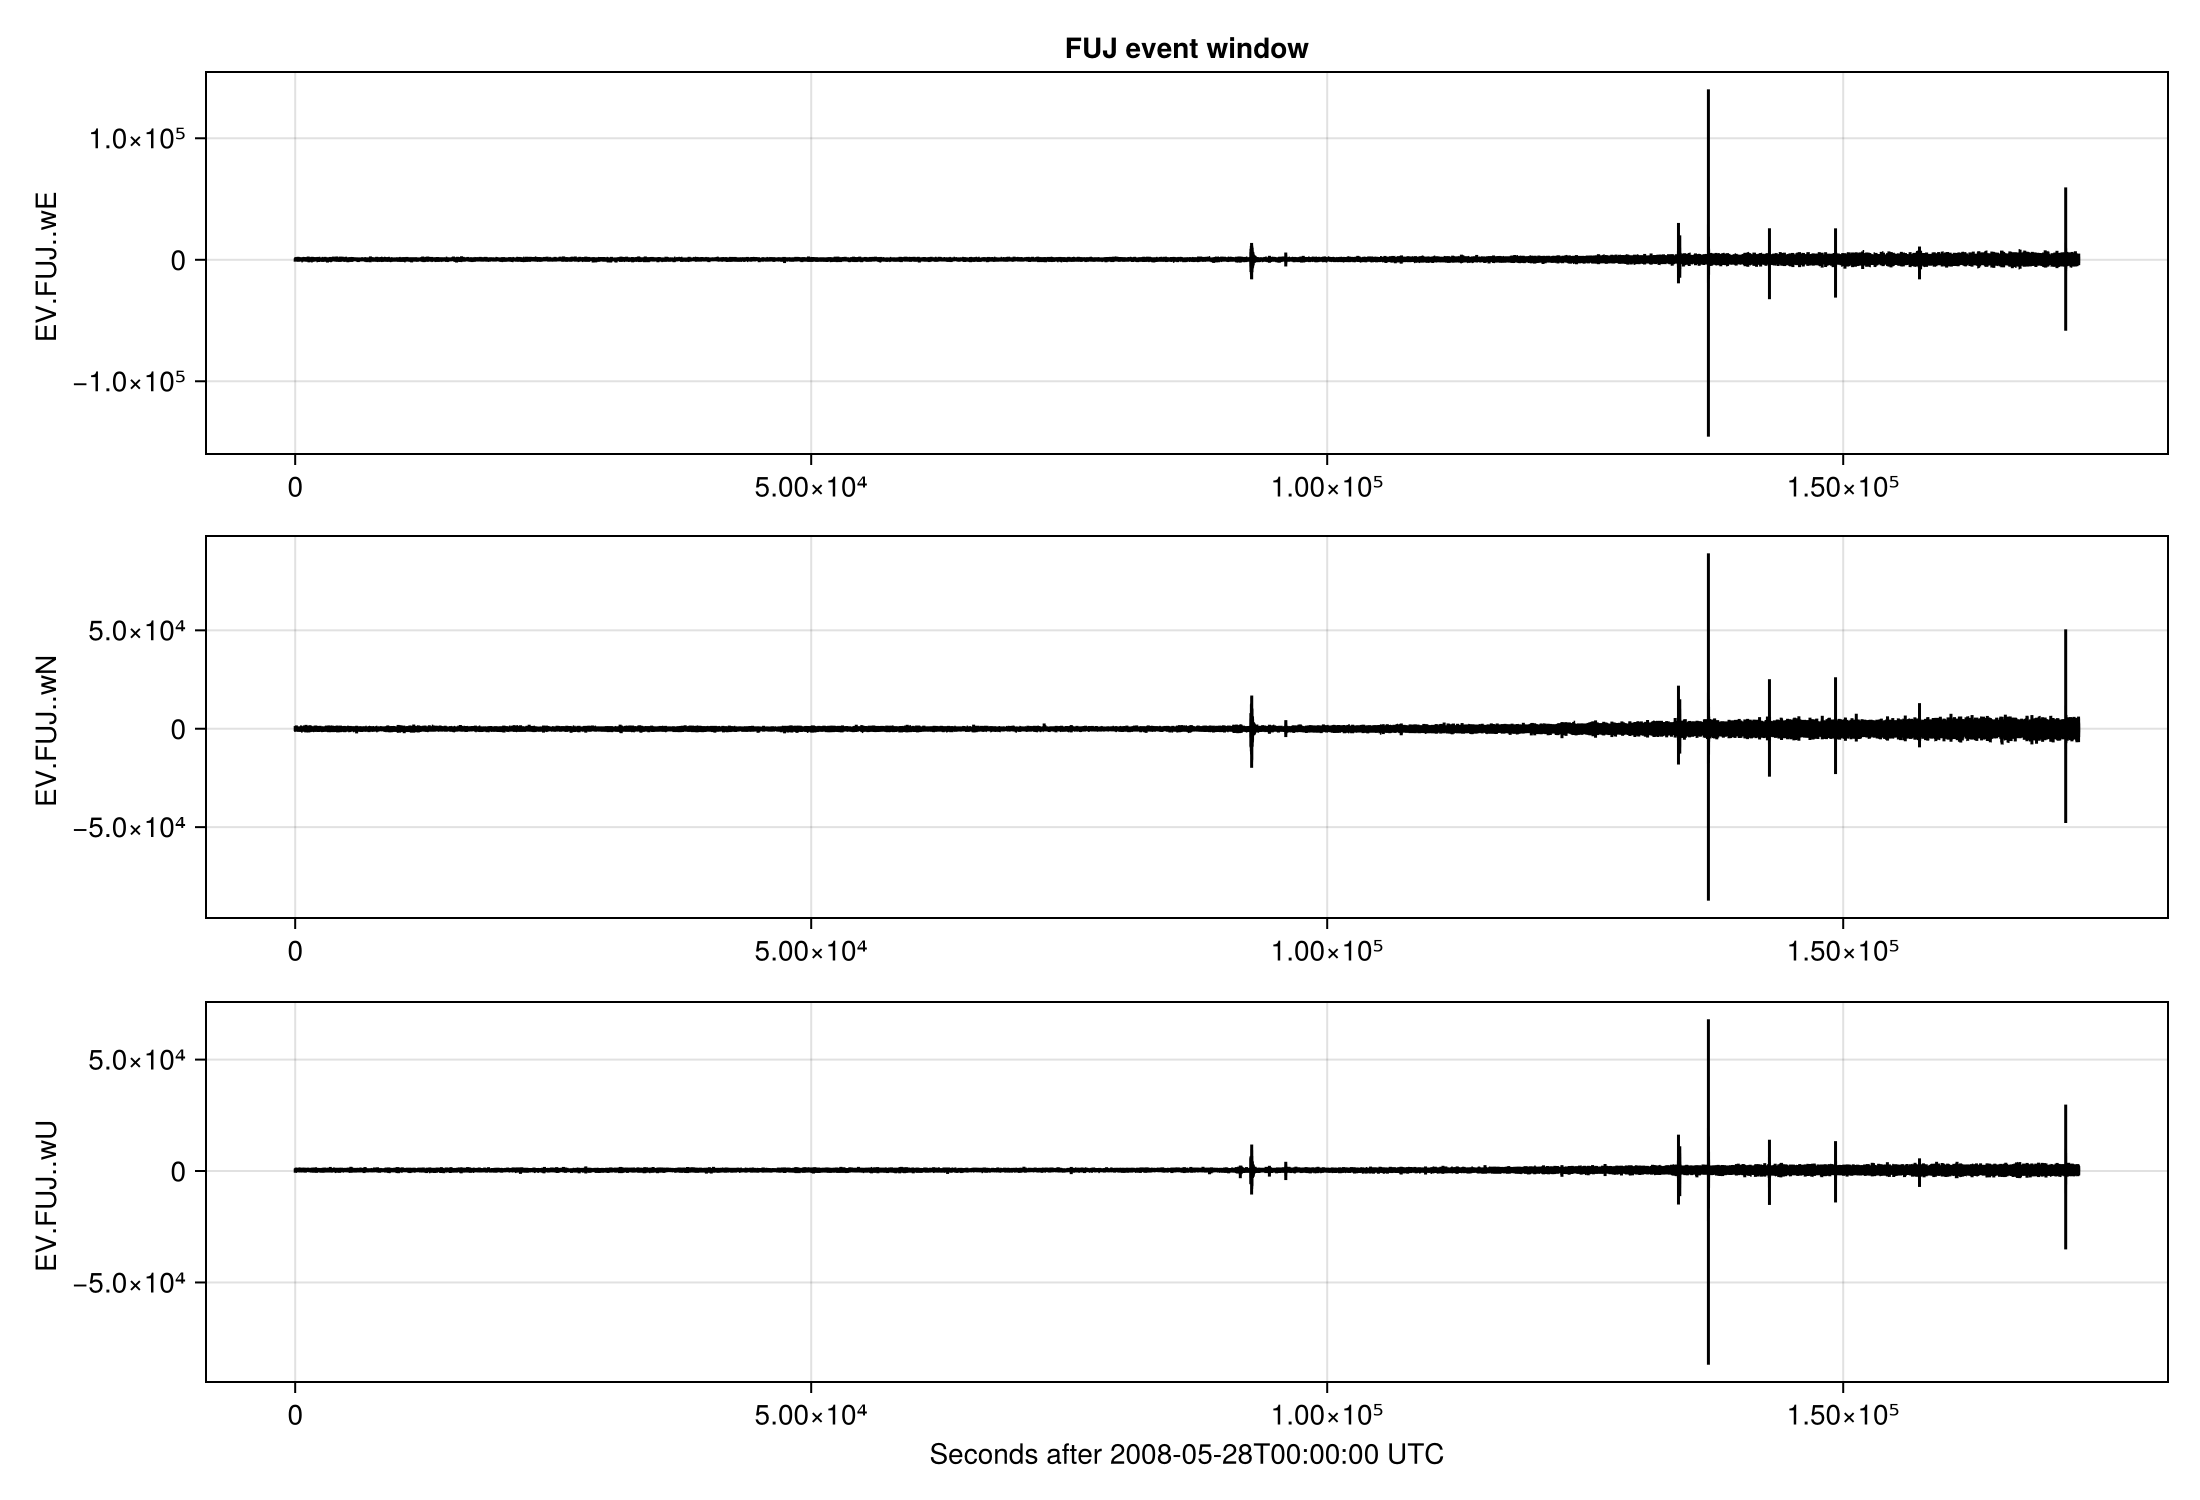

In [7]:

plot_events = read_catalog(
    archive;
    start=start_time,
    stop=end_time,
)

wavefig = plot_waveforms(
    traces;
    #events=plot_events,
    title="FUJ event window",
)
wavefig

In [8]:
specfig = plot_time_frequency(
    traces;
    #events=plot_events,
    window=2.0,
    overlap=0.75,
    title="FUJ time-frequency power",
)

In [12]:

plain = sonify_trace(trace_wU; acceleration=128)
bright = sonify_trace(trace_wU; acceleration=128, harmonics=(0.18, 0.08))
higher = sonify_trace(trace_wU; acceleration=128, octave=3)

write_sonification("audio/plain.wav", plain)
write_sonification("audio/bright.wav", bright)
write_sonification("audio/higher.wav", higher)

#wavplay(bright.signal, bright.sample_rate)

"audio/higher.wav"